First we need a dataset to train on. Let's create a DataSet object directly from huggingface. The avaialable datasets are [here](https://huggingface.co/datasets/fastmachinelearning/collide-1m/tree/main). We want to train on QCD so let's use the "QCD inclusive" dataset which on hugging face is called: QCD_HT50toInf. We set the max_number_of_events to -1 to get all the data but this can be set to whatever is needed

In [1]:
from data.ADdataset import DataSet

/opt/conda/envs/pennylane/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-04-13 15:02:37.897709: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-13 15:02:37.971096: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-13 15:02:39.450644: I tensorflow/core/util/por

In [2]:
from sklearn.model_selection import train_test_split



background_train = DataSet.fromOrginalH5('/eos/user/c/cebrown/RobustQML/AD_dataset/background_for_training')
background_test = DataSet.fromOrginalH5('/eos/user/c/cebrown/RobustQML/AD_dataset/background_for_training')
background_augment_test = background_test

train, test = train_test_split(background_train.data_frame, test_size=0.4)

background_train.data_frame = train
background_test.data_frame = test


background_train.save_h5('ADdataset/background_train')

augment_test, test = train_test_split(background_test.data_frame, test_size=0.5)

background_test.data_frame = test
background_augment_test.data_frame = augment_test

background_test.save_h5('ADdataset/background_test')
background_augment_test.save_h5('ADdataset/background_augment_test')


KeyboardInterrupt: 

In [4]:
background_train.pretty_name = "SM Background"
background_train.plot_inputs('dataset/background_train')

background_test.pretty_name = "SM Background"
background_test.plot_inputs('dataset/background_test')

plot jet features
plot muon features
plot electron features
plot met features
plot jet features
plot muon features
plot electron features
plot met features


<Figure size 640x480 with 0 Axes>

Let's also get the diHiggs -> 4b dataset to be our testing "anomaly" and the minbias to be our "background"

As we are using these datasets for training an autoencoder having very different feature distributions will lead to poor training so let's normalise the data between 0 and 1 by performing a minmax normalisation, i.e. (x - min(x)) / (max(x) - min(x)). If you need a standard deviation normalisation, i.e. (x - mean(x))/ std(x) set minmax in the function call to false.

In [5]:
background.normalise(minmax=True)

Models for training follow a common format. They are a python class that holds a few abstract methods for us to define for a given model. This means that a autoencoder model or Quantum embedding model can be trained with the same .fit command with the same data.

Now let's train a model. First let's create a config dictionary directly. We can also do this with a yaml file like is shown in model/configs. Then create the model from the dictionary, specifying the ouput directly as well


In [6]:
import model
from model.common import fromDict,fromYaml

config_dict = {'model': 'IsolationTreeModel',
               'run_config' : {'verbose' : 2,
                               'debug' : True,
                               'num_threads' : 8},
               'model_config' : {},
               'training_config' :{}}

AE_model = fromDict(config_dict,'output/tree')

Re-created existing directory: output/tree.


In [6]:
import model
from model.common import fromDict,fromYaml

config_dict = {'model': 'AutoEncoderModel',
               'run_config' : {'verbose' : 2,
                               'debug' : True,
                               'num_threads' : 8},
               'model_config' : {'name' : 'autoencoder',
                                 'encoder_layers' : [32,16],
                                 'decoder_layers' : [24,32,64,128],
                                 'latent_dim': 8},
               'training_config' :{'epochs' : 100,
                                   'batch_size' : 256,
                                   'learning_rate' : 0.001,
                                   'validation_split' : 0.1,
                                   'EarlyStopping_patience' : 10,
                                   'ReduceLROnPlateau_factor' : 0.5,
                                   'ReduceLROnPlateau_patience' : 5,
                                   'ReduceLROnPlateau_min_lr' : 0.00001}}

AE_model = fromDict(config_dict,'output/autoencoder')

# Alternatively like this from a yaml config
#AE_model = fromYaml('model/configs/AutoEncoder.yaml','output/autoencoder')

Re-created existing directory: output/autoencoder.


First we need to know the input vector shape which we can derive from the input dataset. 
Then we can build the model and compile it ready for training

In [7]:
input_shape = len(background.training_columns)
AE_model.build_model(input_shape)
AE_model.compile_model()
    


Now we can fit the model using the dataset. We use the "get_training_dataset()" function to ensure that the DataSet object passes a numpy array of the inputs rather than a weird pandas dataframe that isn't supported by all training frameworks

In [8]:
AE_model.fit(background.data_frame,background.training_columns)


Feature L1T_PUPPIMET_Eta is a NUMERICAL feature with all values recorded in the data spec set to the same value. The feature will likely not be useful during model training.
Train model on 13451915 examples


[Warning] On large datasets, distributed training can significantly speed training. See: https://ydf.readthedocs.io/en/latest/tutorial/distributed_training
[Warning] On large datasets, using discretized numerical features (i.e. `discretize_numerical_columns=True`) can significantly speed-up training without impact on model quality.


Model trained in 0:00:00.105310


In [ ]:
ato4l = DataSet.fromOrginalH5('/eos/user/c/cebrown/RobustQML/AD_dataset/Ato4l_lepFilter_13TeV_filtered')
ato4l.save_h5('dataset/ato4l')
ato4l.pretty_name = "A -> 4l"
ato4l.plot_inputs('dataset/ato4l')
#BlackBox = DataSet.fromOrginalH5('/eos/user/c/cebrown/RobustQML/AD_dataset/background_for_training')
hChToTauNu = DataSet.fromOrginalH5('/eos/user/c/cebrown/RobustQML/AD_dataset/hChToTauNu_13TeV_PU20_filtered')
hChToTauNu.save_h5('dataset/hChToTauNu')
hChToTauNu.pretty_name = "H+ -> Tau Nu"
hChToTauNu.plot_inputs('dataset/hChToTauNu')
hToTauTau = DataSet.fromOrginalH5('/eos/user/c/cebrown/RobustQML/AD_dataset/hToTauTau_13TeV_PU20_filtered')
hToTauTau.save_h5('dataset/hToTauTau')
hToTauTau.pretty_name = "h -> Tau Tau"
hToTauTau.plot_inputs('dataset/hToTauTau')
leptoquark = DataSet.fromOrginalH5('/eos/user/c/cebrown/RobustQML/AD_dataset/leptoquark_LOWMASS_lepFilter_13TeV_filtered')
leptoquark.save_h5('dataset/leptoquark')
leptoquark.pretty_name = "leptoquark"
leptoquark.plot_inputs('dataset/leptoquark')


['L1T_PUPPIMET_MET', 'L1T_PUPPIMET_Eta', 'L1T_PUPPIMET_Phi', 'L1T_Electron_PT0', 'L1T_Electron_Eta0', 'L1T_Electron_Phi0', 'L1T_Electron_PT1', 'L1T_Electron_Eta1', 'L1T_Electron_Phi1', 'L1T_Electron_PT2', 'L1T_Electron_Eta2', 'L1T_Electron_Phi2', 'L1T_Electron_PT3', 'L1T_Electron_Eta3', 'L1T_Electron_Phi3', 'L1T_MuonTight_PT0', 'L1T_MuonTight_Eta0', 'L1T_MuonTight_Phi0', 'L1T_MuonTight_PT1', 'L1T_MuonTight_Eta1', 'L1T_MuonTight_Phi1', 'L1T_MuonTight_PT2', 'L1T_MuonTight_Eta2', 'L1T_MuonTight_Phi2', 'L1T_MuonTight_PT3', 'L1T_MuonTight_Eta3', 'L1T_MuonTight_Phi3', 'L1T_JetPuppiAK4_PT0', 'L1T_JetPuppiAK4_Eta0', 'L1T_JetPuppiAK4_Phi0', 'L1T_JetPuppiAK4_PT1', 'L1T_JetPuppiAK4_Eta1', 'L1T_JetPuppiAK4_Phi1', 'L1T_JetPuppiAK4_PT2', 'L1T_JetPuppiAK4_Eta2', 'L1T_JetPuppiAK4_Phi2', 'L1T_JetPuppiAK4_PT3', 'L1T_JetPuppiAK4_Eta3', 'L1T_JetPuppiAK4_Phi3', 'L1T_JetPuppiAK4_PT4', 'L1T_JetPuppiAK4_Eta4', 'L1T_JetPuppiAK4_Phi4', 'L1T_JetPuppiAK4_PT5', 'L1T_JetPuppiAK4_Eta5', 'L1T_JetPuppiAK4_Phi5', 'L1T_

<Figure size 640x480 with 0 Axes>

In [ ]:
from data.ADdataset import DataSet
labels = { "ato4l" :1, "hChToTauNu" : 2, "hToTauTau" : 3, "leptoquark" : 4, "blackbox" : 5,"background_test" : 0}
for datasets in labels.keys():
        data_test = DataSet.fromH5('dataset/'+datasets)
        data_test.drop_a_soft_one('jet')
        data_test.eta_smear()
        data_test.pt_smear()
        data_test.phi_smear()
        data_test.save_h5('dataset/'+datasets+'_augmented')
        data_test.plot_inputs('dataset/'+datasets+'_augmented')

/opt/conda/envs/tagger/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-02-13 11:08:41.413055: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-13 11:08:41.448968: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-13 11:08:42.415097: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may 

              index  L1T_PUPPIMET_MET  L1T_PUPPIMET_Eta  L1T_PUPPIMET_Phi  \
count  55969.000000      55969.000000           55969.0      55969.000000   
mean   27984.000000         29.463986               0.0         -0.005421   
std    16157.002945         20.793319               0.0          1.814142   
min        0.000000          0.131513               0.0         -3.141588   
25%    13992.000000         16.226780               0.0         -1.571571   
50%    27984.000000         25.855325               0.0         -0.005430   
75%    41976.000000         37.811120               0.0          1.564539   
max    55968.000000        448.620954               0.0          3.141572   

       L1T_Electron_PT0  L1T_Electron_Eta0  L1T_Electron_Phi0  \
count      55969.000000       55969.000000       55969.000000   
mean          23.423805           0.003491          -0.000248   
std           27.013305           1.137098           1.479763   
min            0.000000          -3.000000    

<Figure size 640x480 with 0 Axes>

In [ ]:

blackbox = DataSet.fromH5('/eos/user/c/cebrown/RobustQML/AD_dataset/processed/blackbox/test')
blackbox.plot_inputs('dataset/blackbox')

print(blackbox.data_frame.head())

[770383 880350 202390 ...  58398 763062  67606]
1001000
[      0       1       2 ... 1000997 1000998 1000999]
1001000
===Full Data Saved===
plot jet features
plot muon features
plot electron features
plot met features


<Figure size 640x480 with 0 Axes>

In [ ]:
import pandas as pd


labels = {"background" : 0, "ato4l" :1, "hChToTauNu" : 2, "hToTauTau" : 3, "leptoquark" : 4}
dataset_list = []
for datasets in labels.keys():
    data_test = DataSet.fromH5('dataset/'+datasets)
    data_test.normalise()
    data_test.set_label(labels[datasets])
    dataset_list.append(data_test)
        
full_data_frame = pd.concat([dataset.data_frame.sample(n=5000) for dataset in dataset_list])
full_data_frame = full_data_frame.sample(frac=1)

AE_model.AD_model.analyze(full_data_frame, sampling=1.0)


In [ ]:
from plot.basic import clusters
import numpy as np
distances = AE_model.AD_model.distance(full_data_frame[dataset_list[0].training_columns].iloc[0:25000])
clusters(distances,labels=np.array(full_data_frame['event_label']),plot_dir='', label_to_names={v: k for k, v in labels.items()})

Save it so we can use it later

In [9]:
AE_model.save()

Model saved to output/tree/model/saved_model/


Plot the loss to see how it trained

In [ ]:
AE_model.plot_loss()

Let's have a look at the model outputs first by runnning predict on our datasets (make sure they are normalised) and then using the histo plotting function to visualise the output. What we hopefully see is that the QCD training dataset has got a low anomaly score because our model has trained on this. Minbias should look not very anomalous compared to QCD and HH->4b should look the most anomalous.

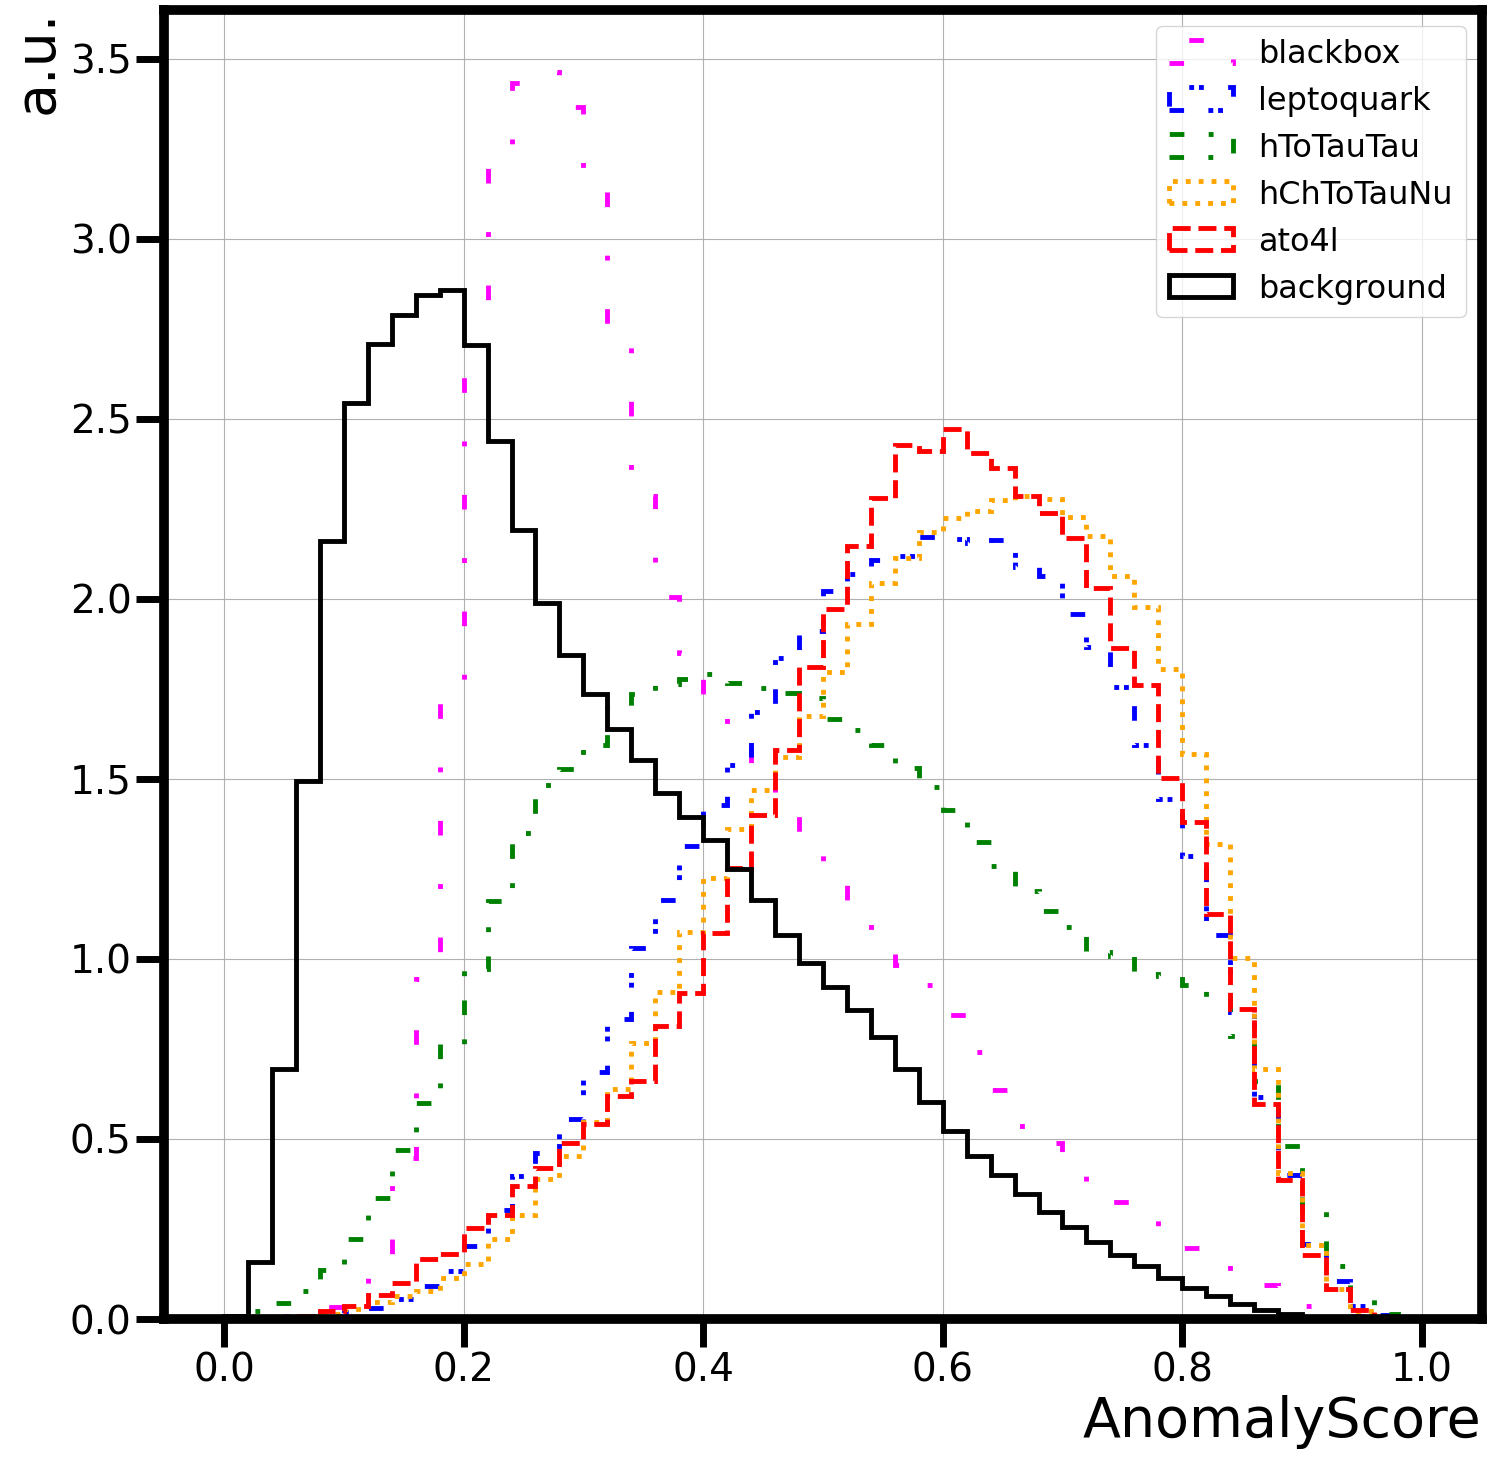

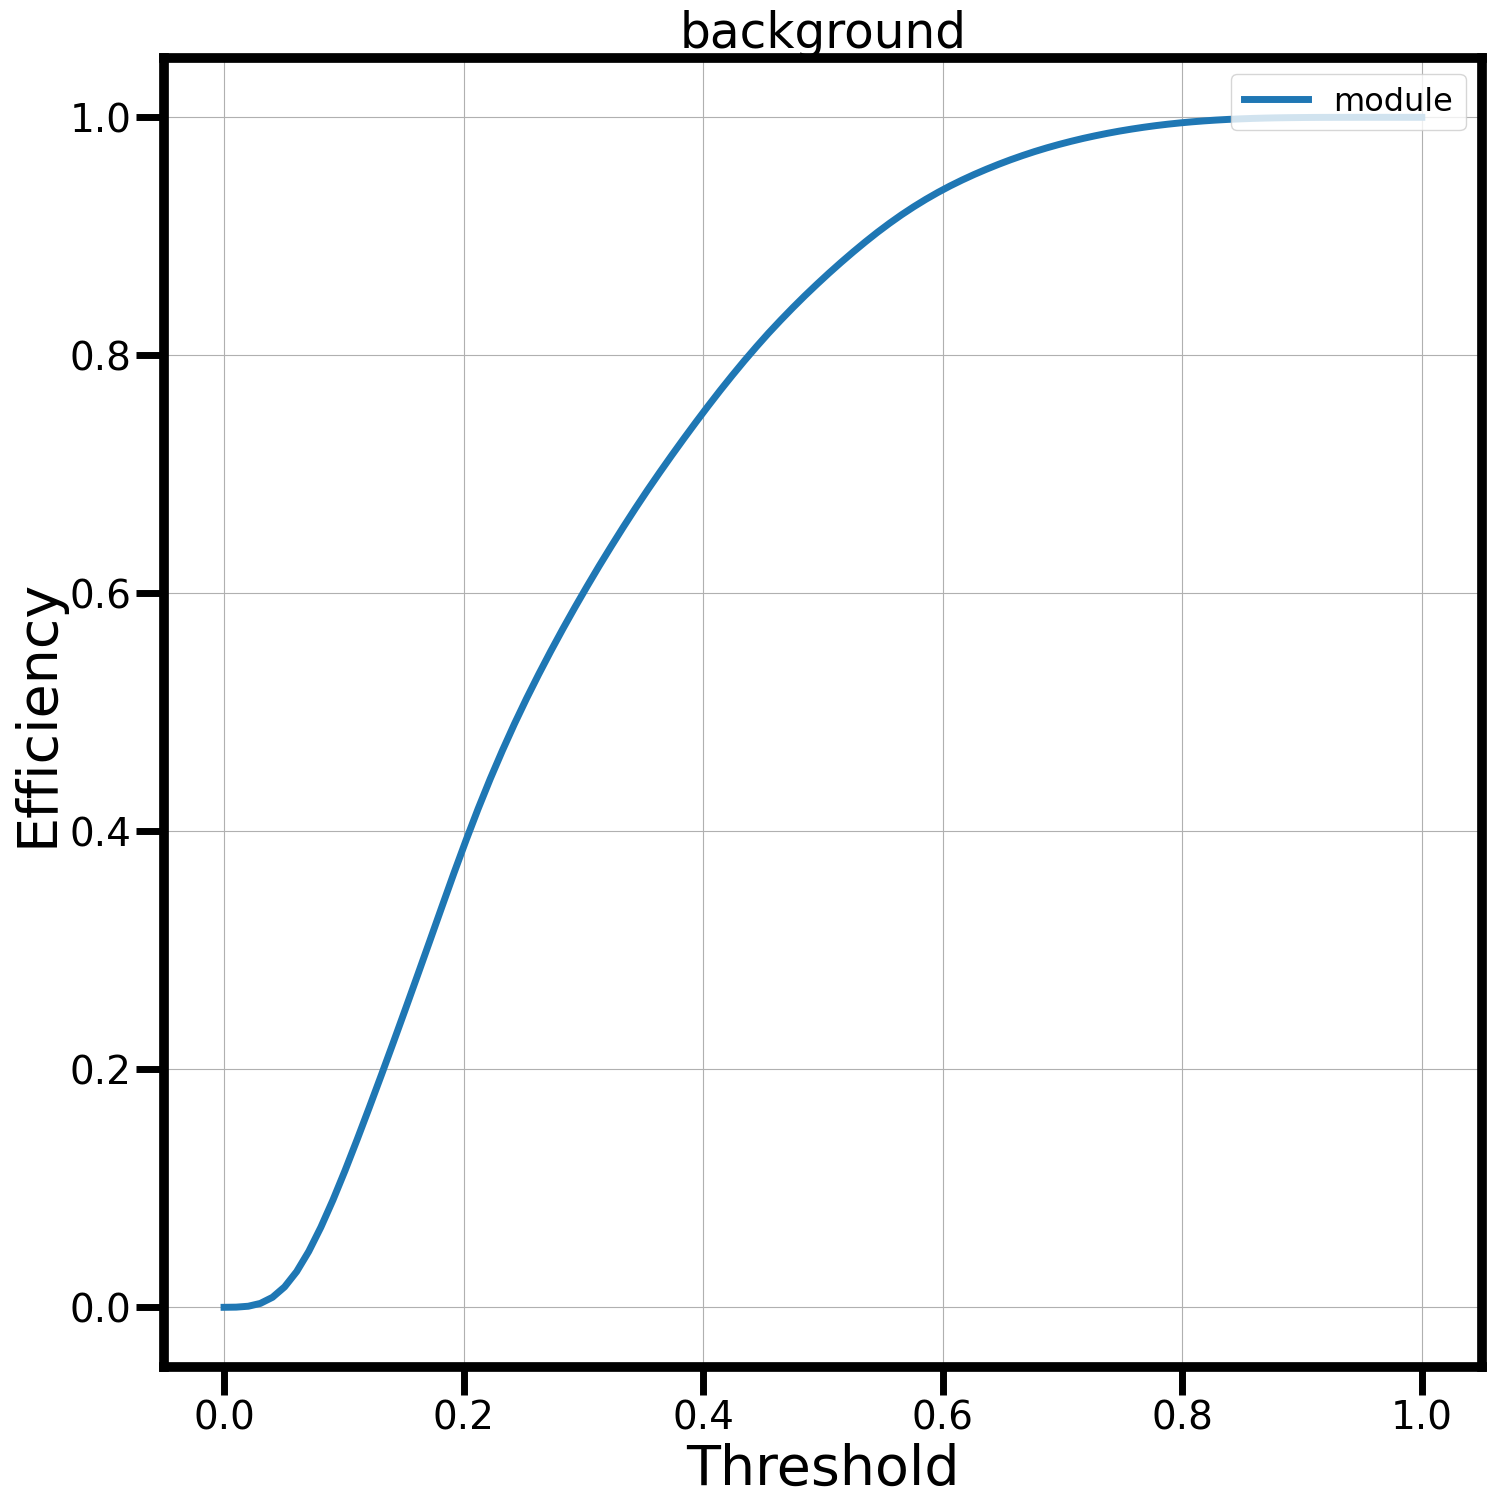

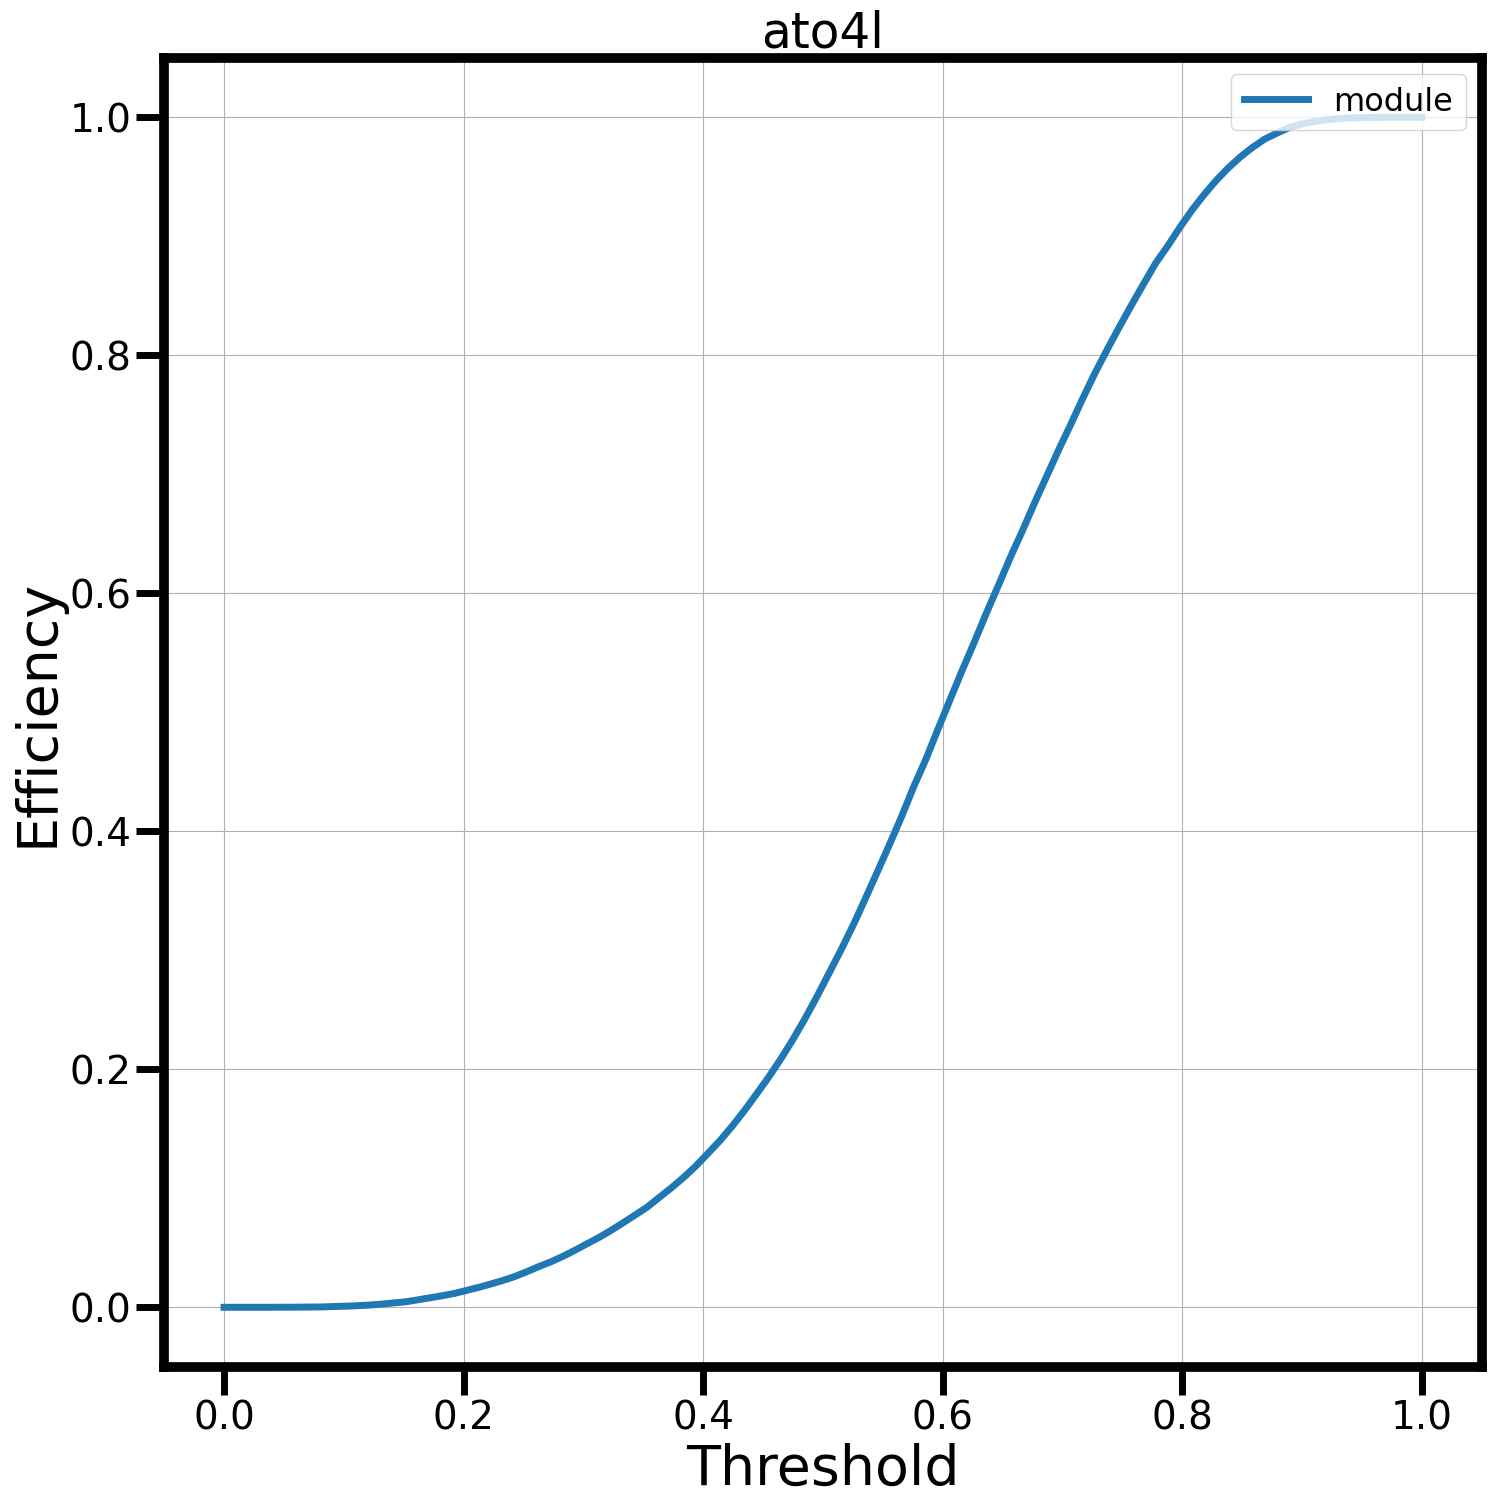

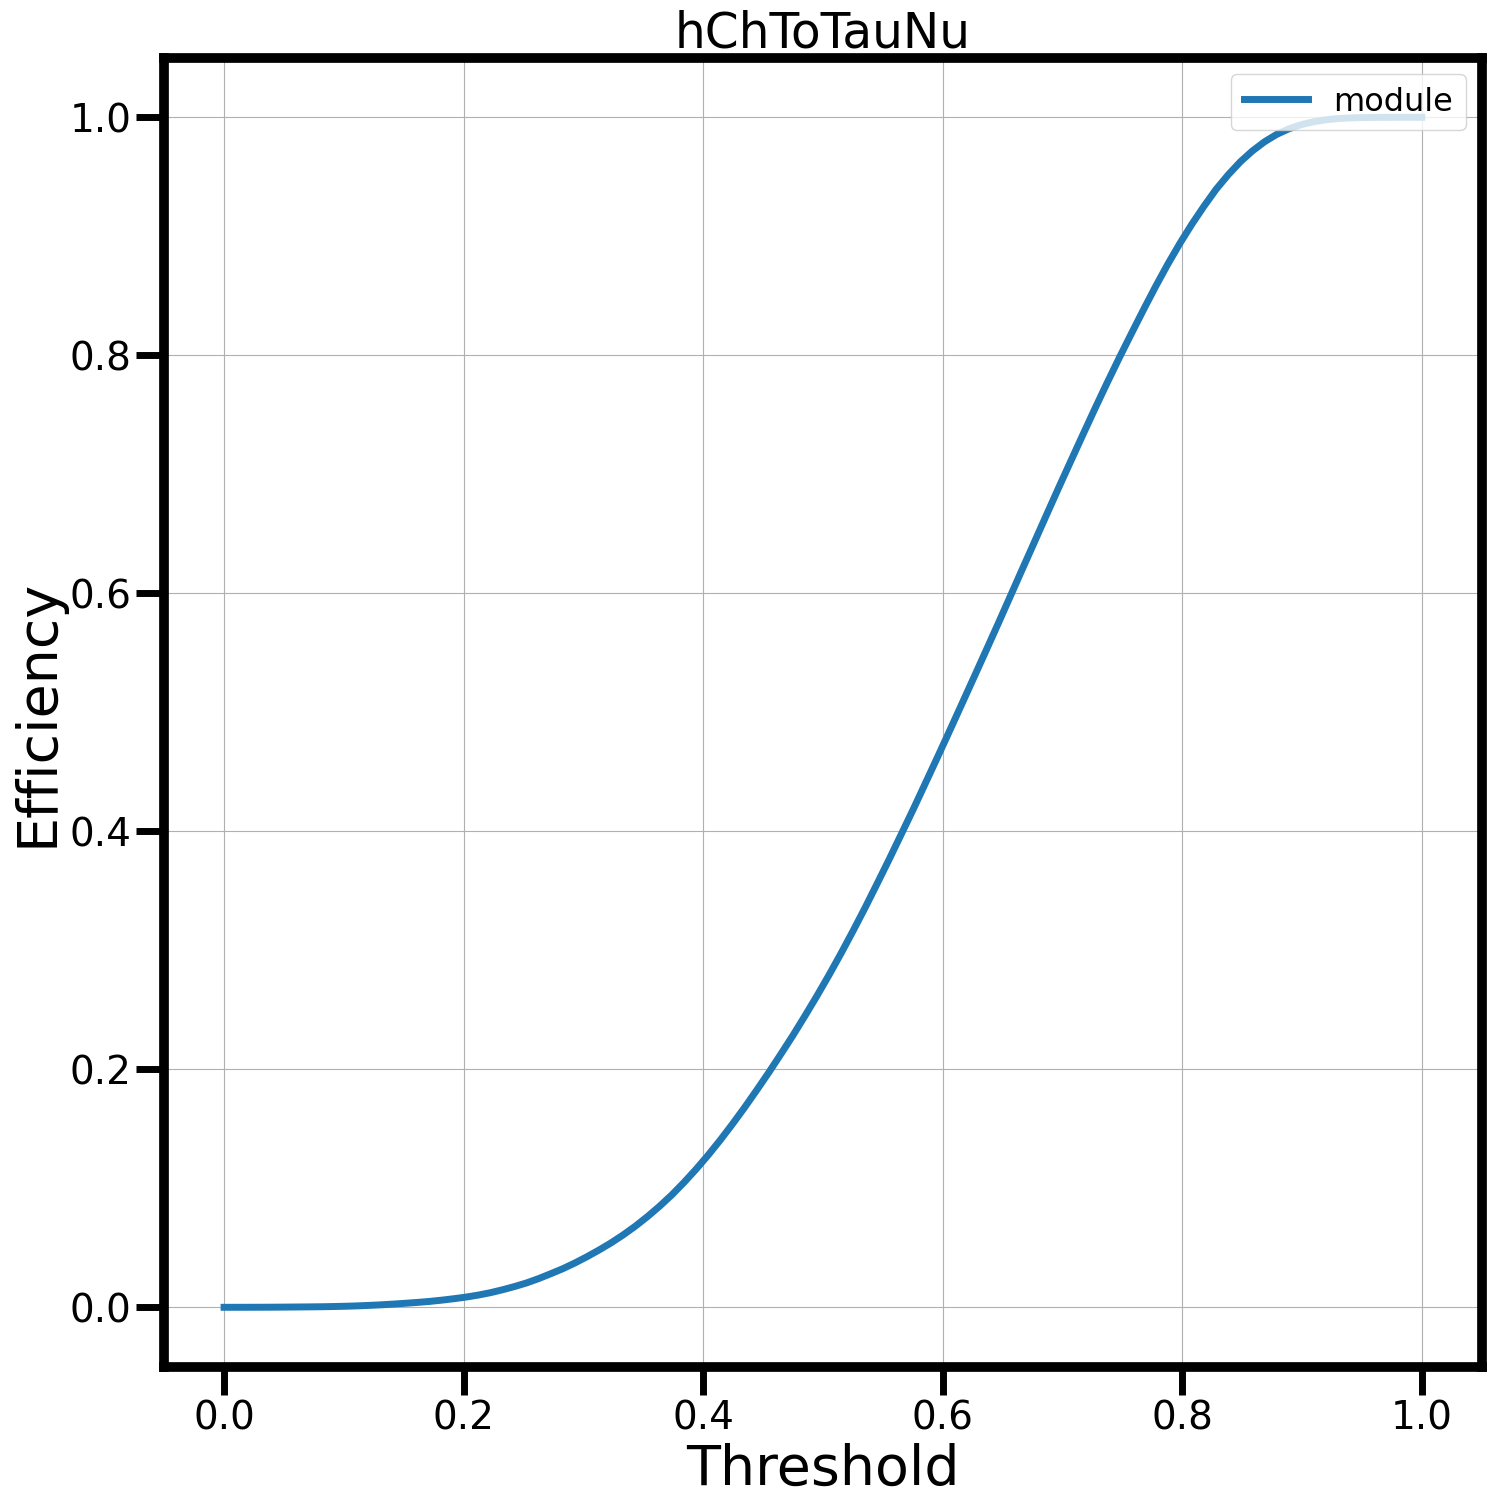

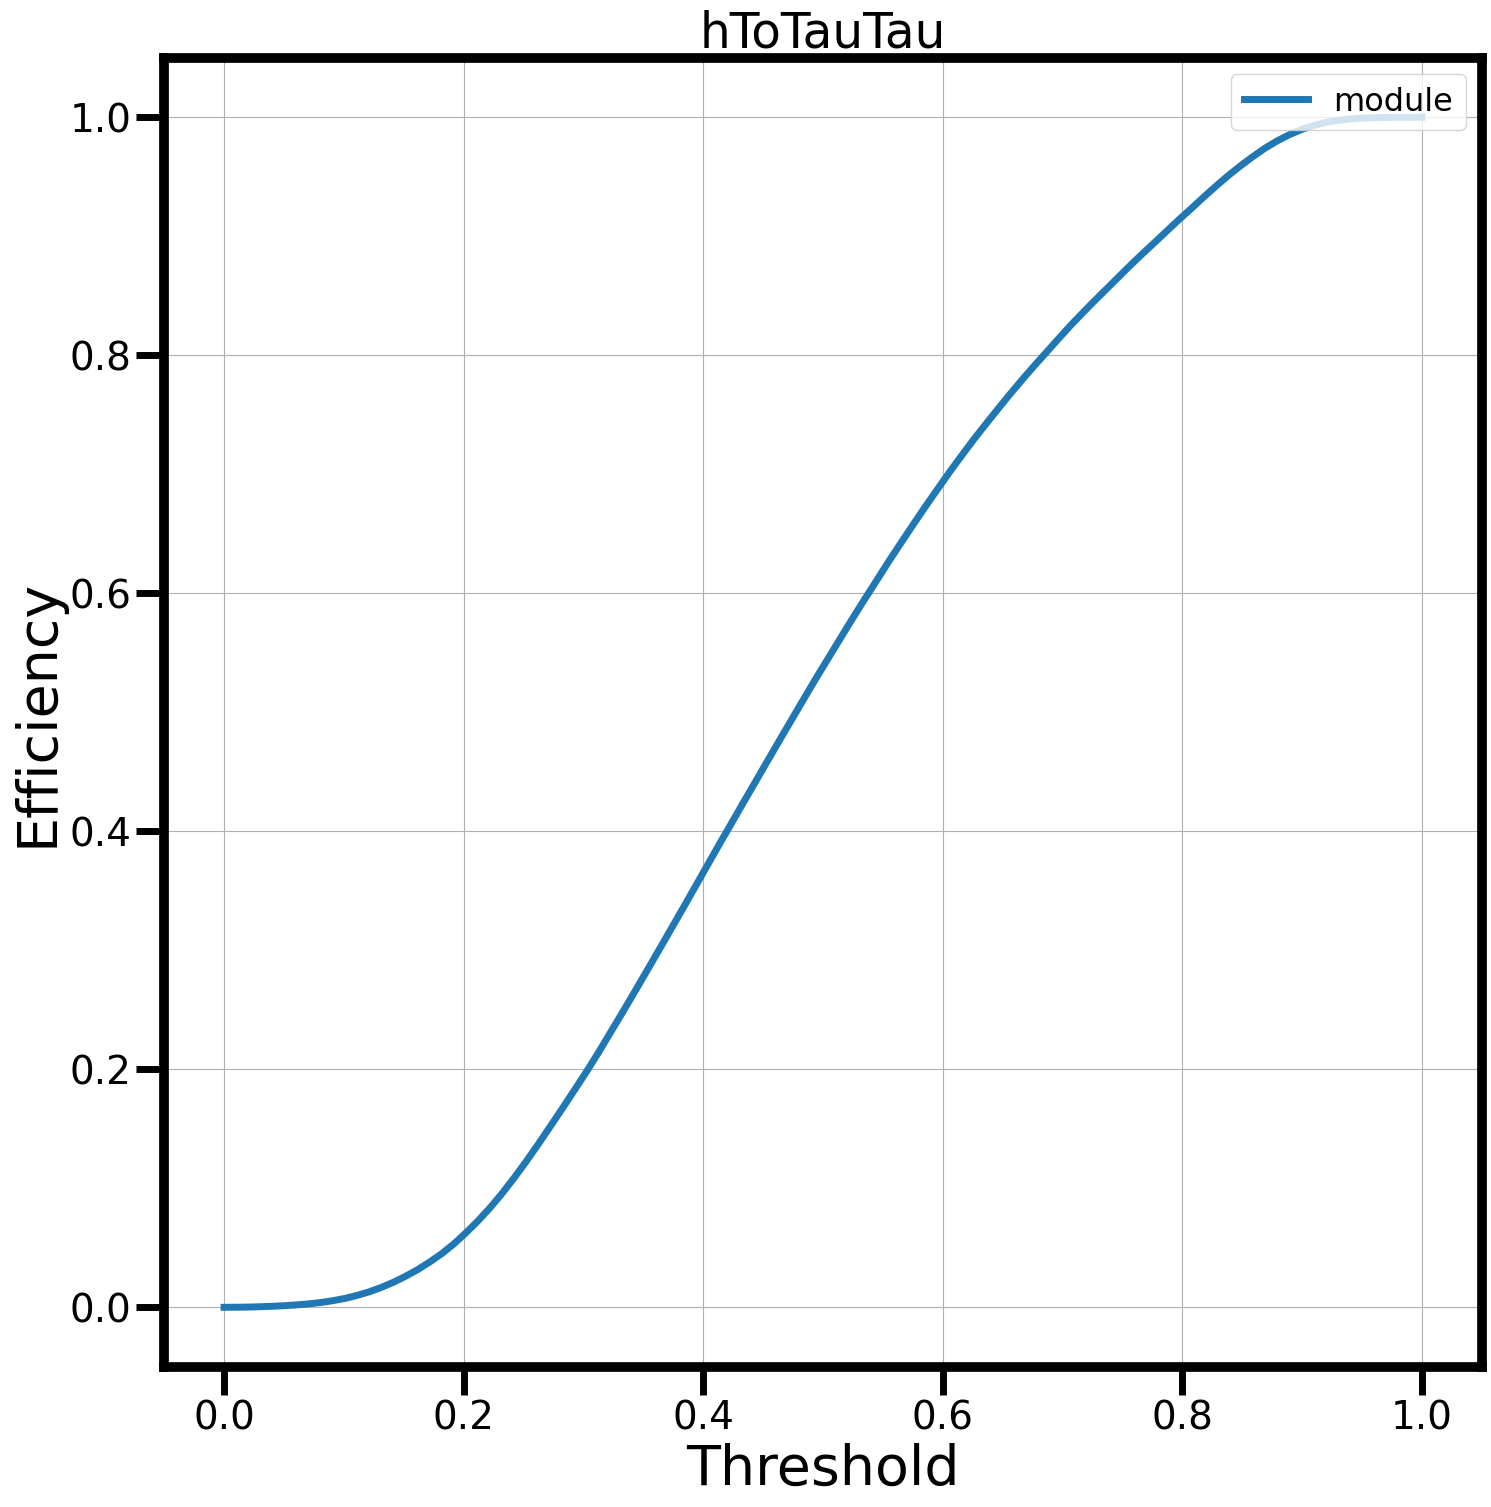

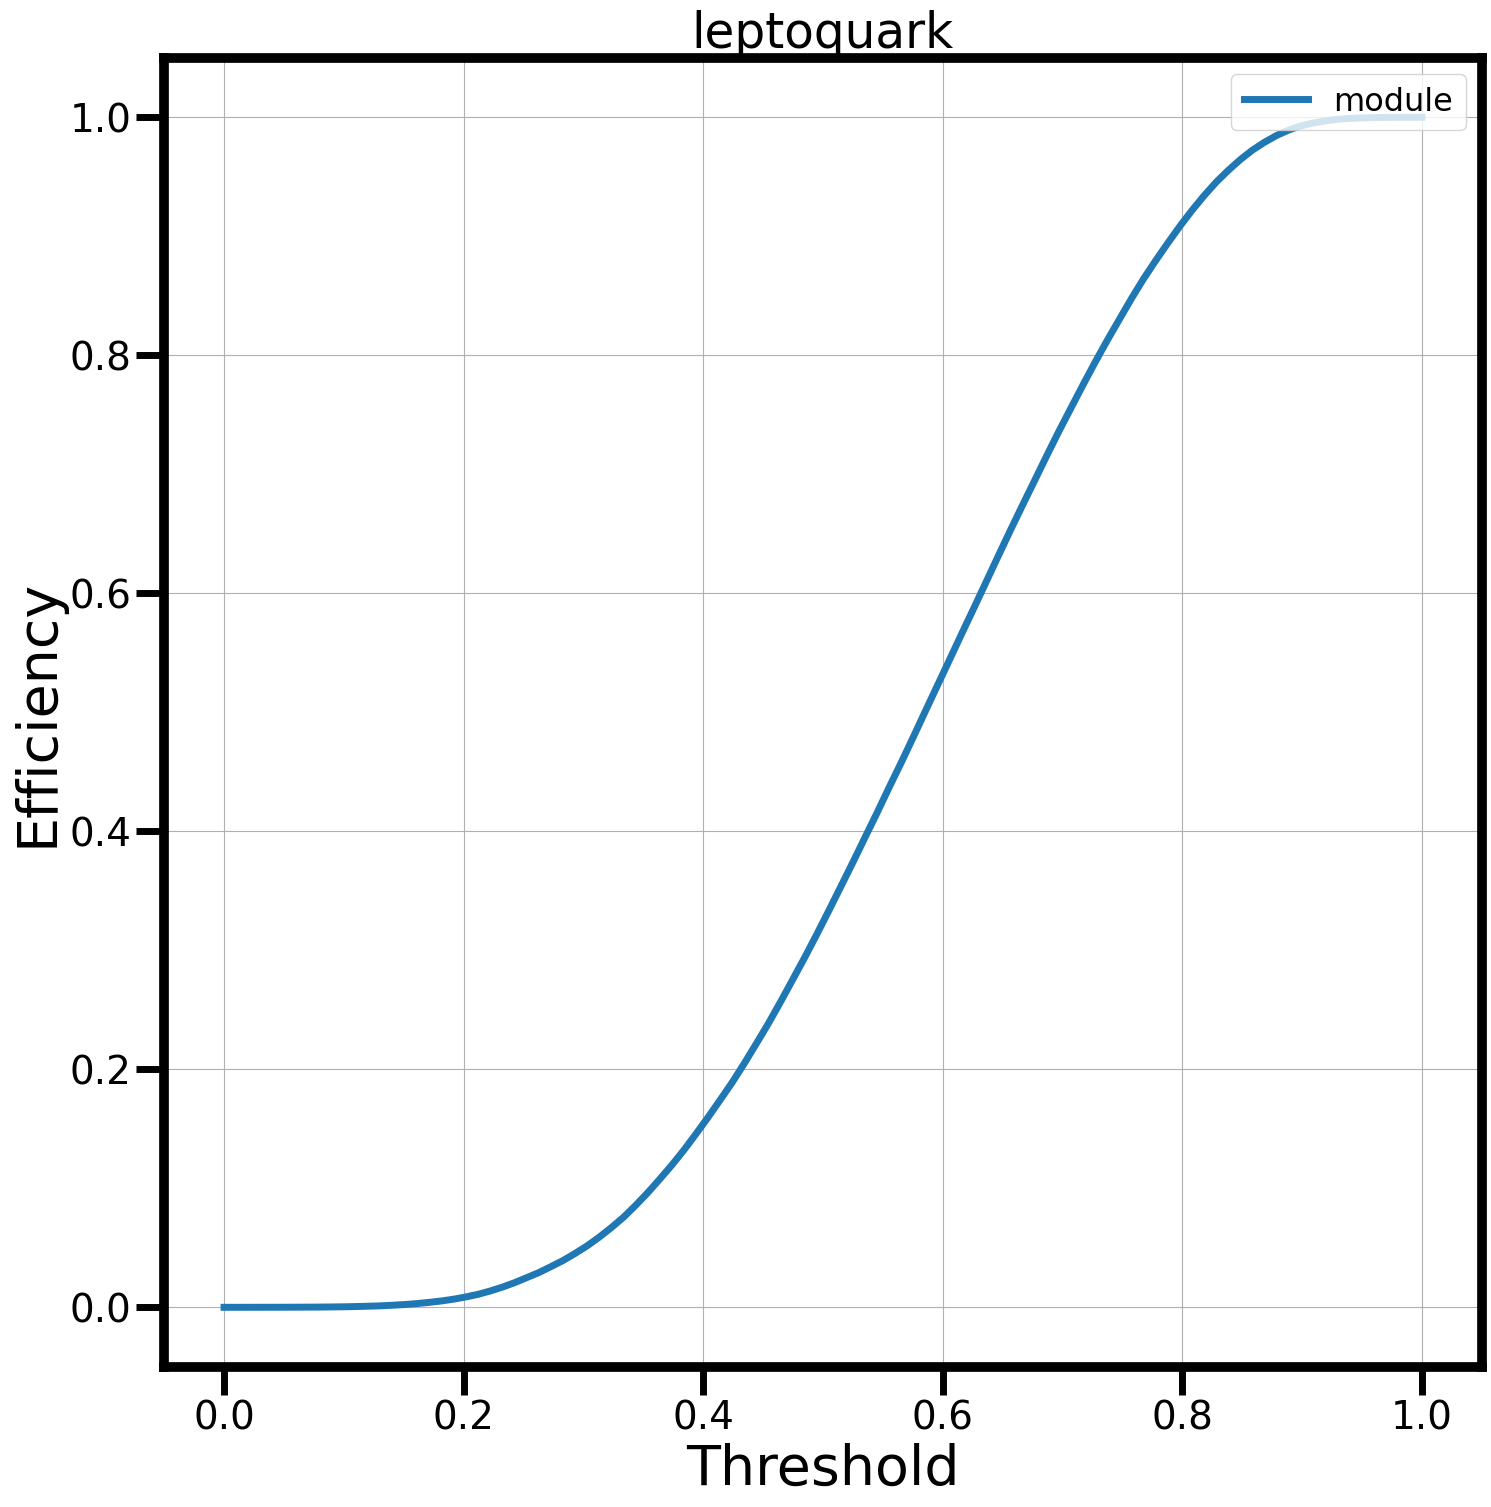

<Figure size 1700x1700 with 0 Axes>

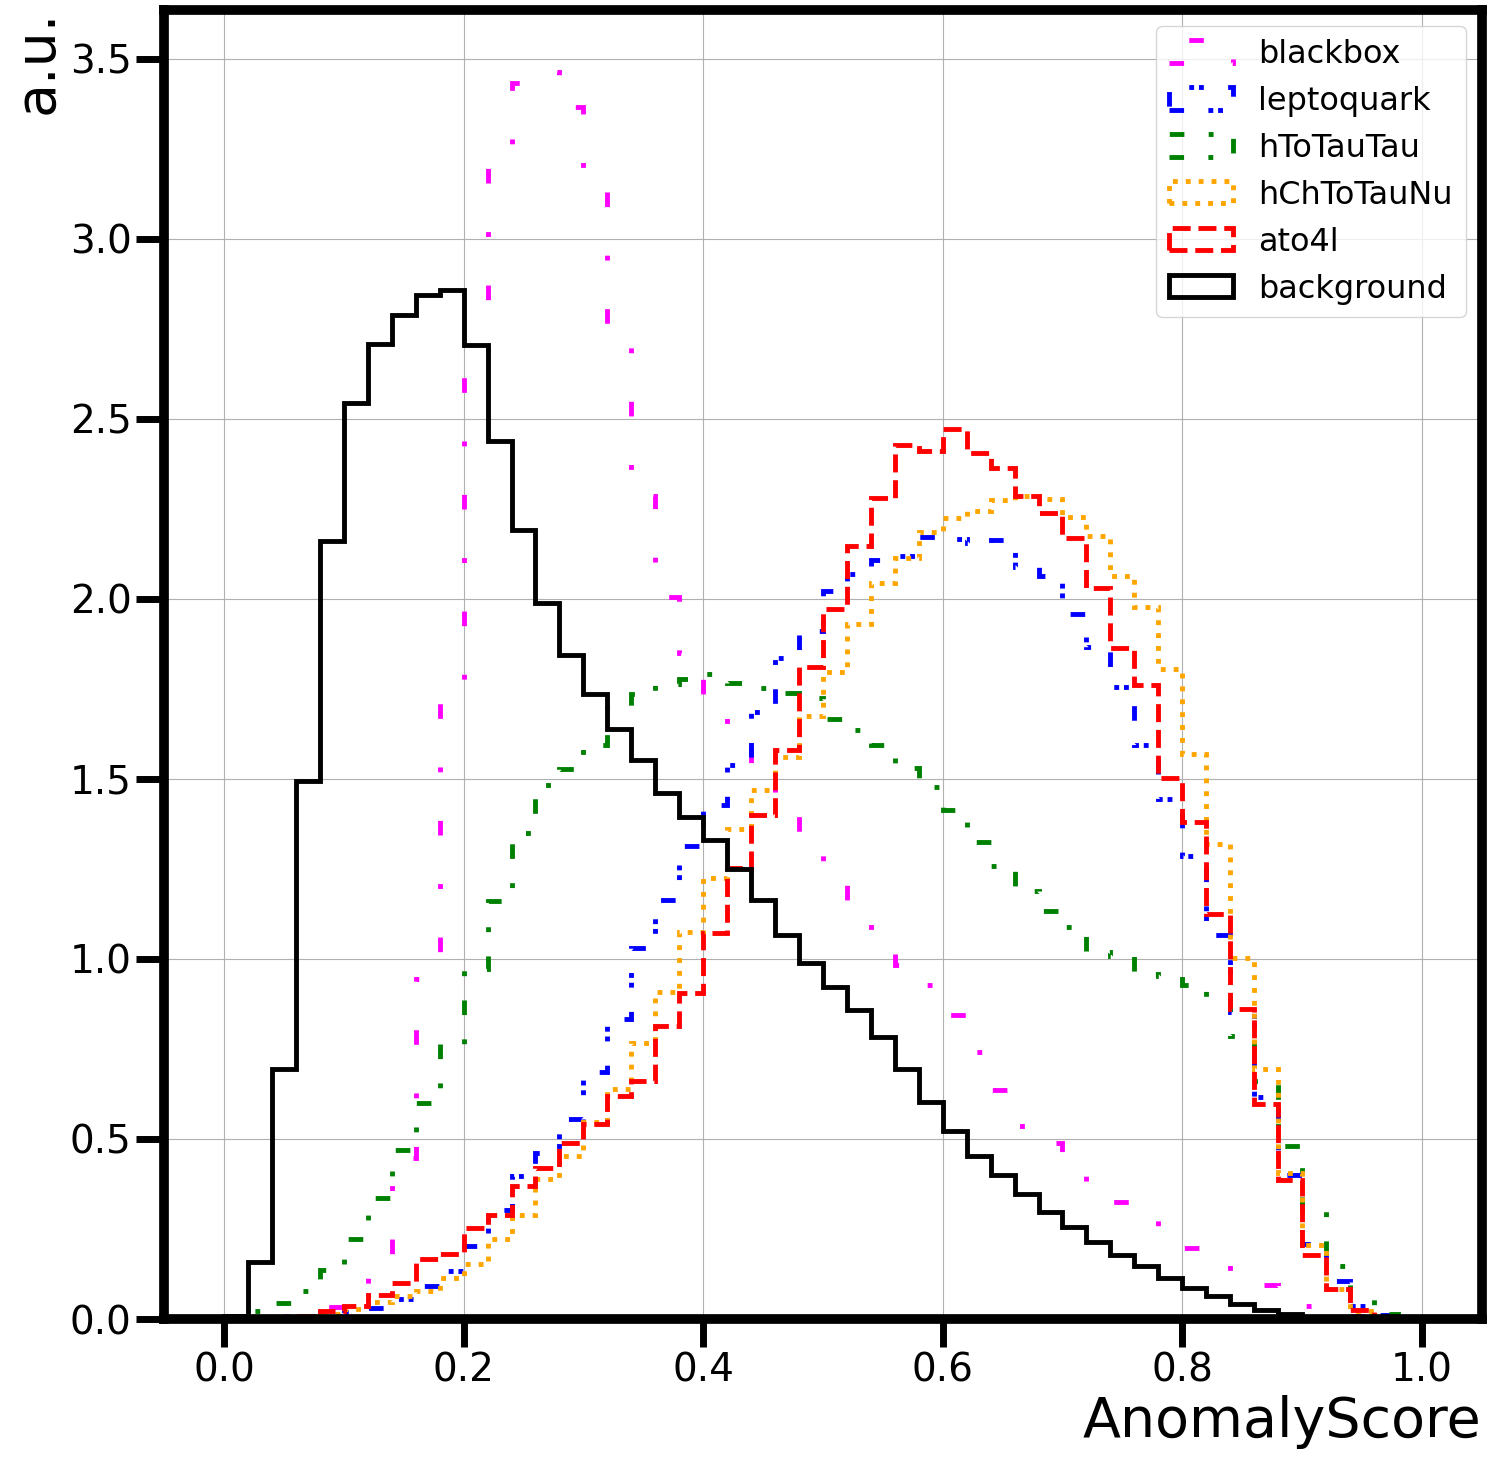

In [12]:
from plot import style
from plot.basic import error_residual, plot_histo, rates,efficiency
training_columns = background.training_columns
labels = {"background" : {}, "ato4l" :{}, "hChToTauNu" : {}, "hToTauTau" : {}, "leptoquark" : {},"blackbox" : {}}
for datasets in labels.keys():
    data_test = DataSet.fromH5('dataset/'+datasets)
    data_test.normalise()
    model_outputs = AE_model.predict(data_test.data_frame,training_columns)
    efficiency_out = efficiency(type(model).__name__,datasets,model_outputs)
    labels[datasets] = {'predictions' : model_outputs,'efficiencies' : efficiency_out,'dataset':data_test}
    
plot_histo([labels[dataset]['predictions'] for dataset in labels.keys()], 
           [dataset for dataset in labels.keys()], 
            '', 
            'AnomalyScore', 
            'a.u.', 
            log = 'linear', 
            x_range=(0, 1), 
            bins = 50)

Now let's pretend this algorithm is in a trigger. First let's derive the trigger rate, i.e how many times we accept a trigger decision. We base rates on a minbias sample. At an anomaly detection threshold of 0 our trigger rate should be 100% and at a threshold of 1 our trigger rate should be 0. Between 0 and 1 we divide the threshold up into equally sized bins and work out what percentage of minimum bias events we encapsulate within that threshold thus giving us the background rate of our trigger for a given model threshold.

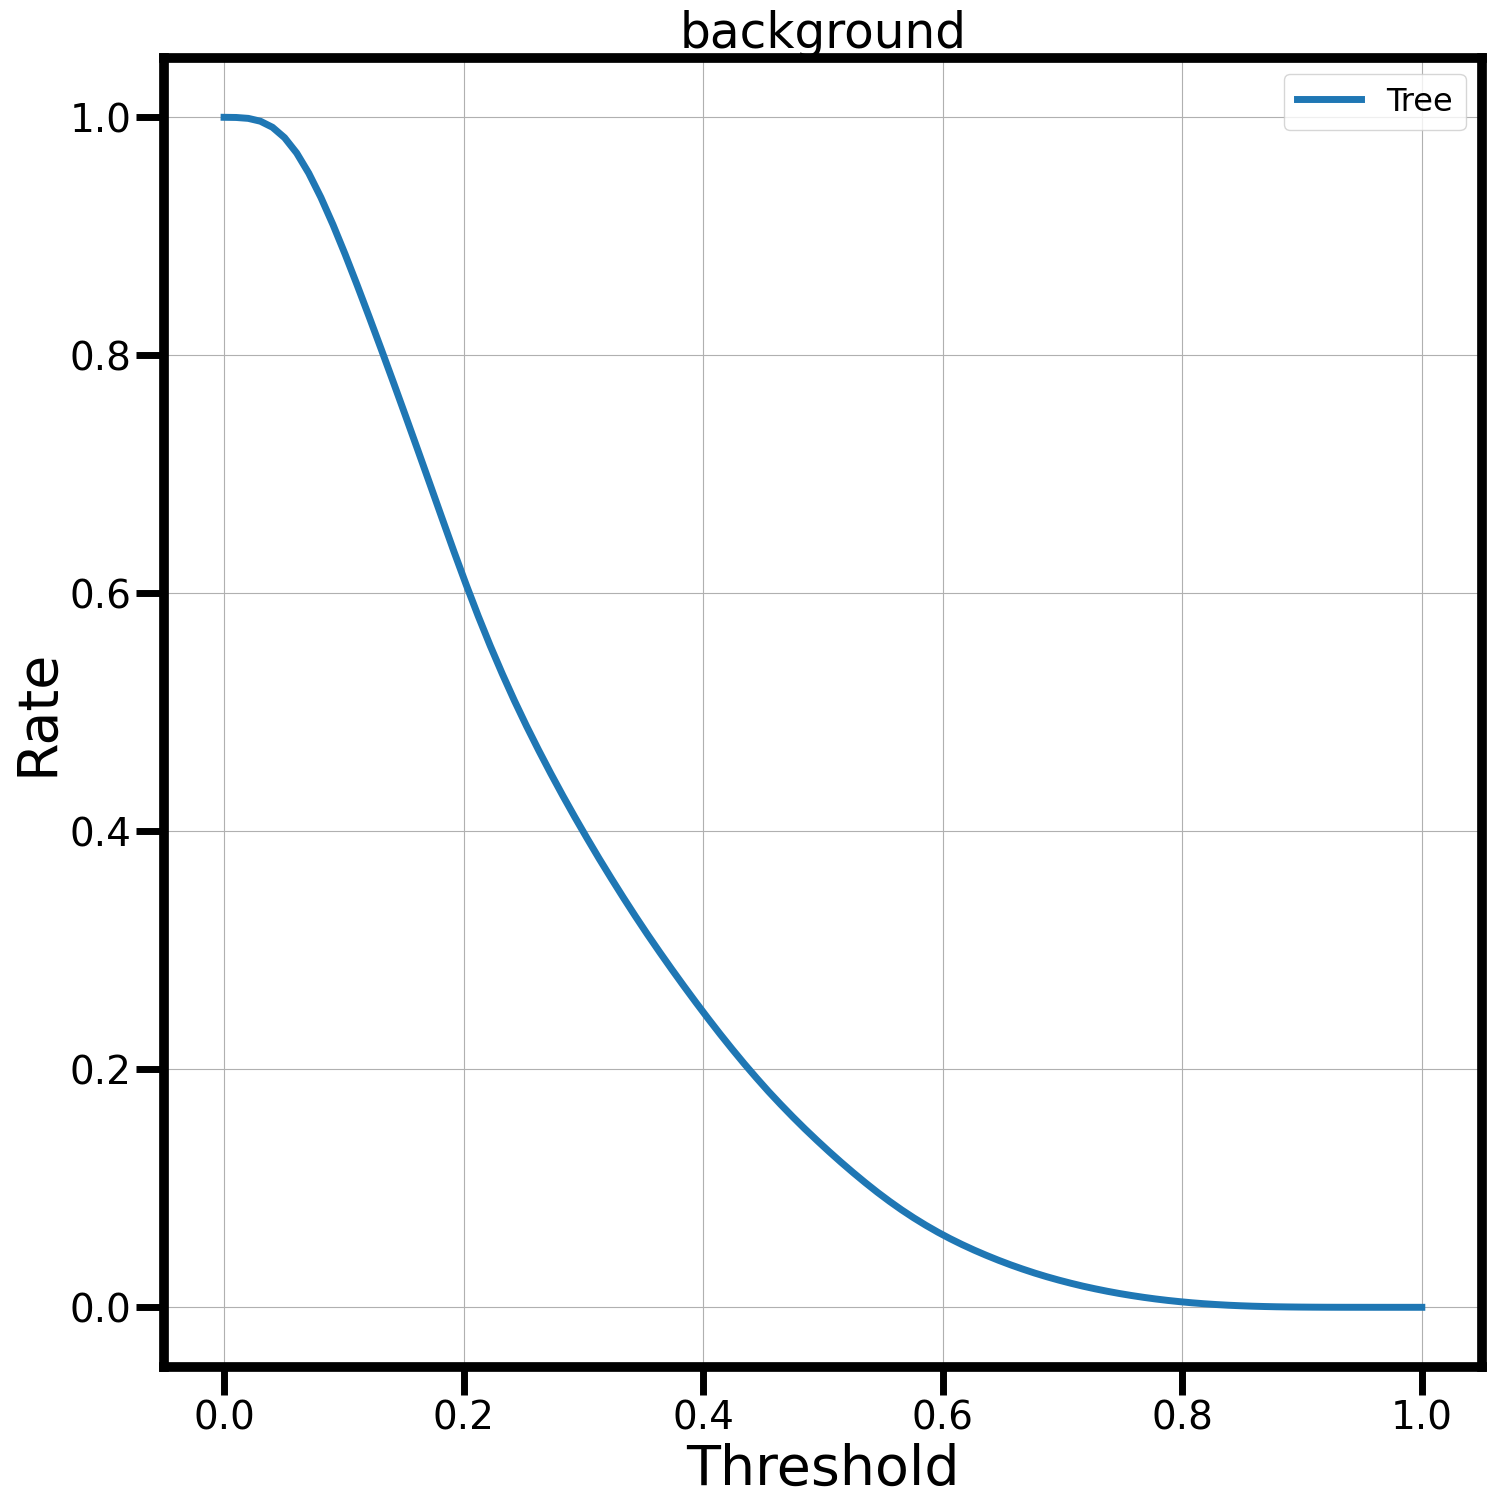

In [14]:
background_rates = rates("Tree",'background',labels['background']['predictions'])

Now we can calculate the efficiency of the model with a given sample. For all samples the efficiency is 0 at a threshold of 0 and 100% at a threshold of 1. As we vary the threshold we capture more of the distribution of events, imagine sweeping a line from right to left of the model output plot and summing the % of total events above that threshold, for QCD we see the drop off in efficiency at a low value of the threshold but for HHbbbb as they look more anomalous a higher threshold can capture the events. 

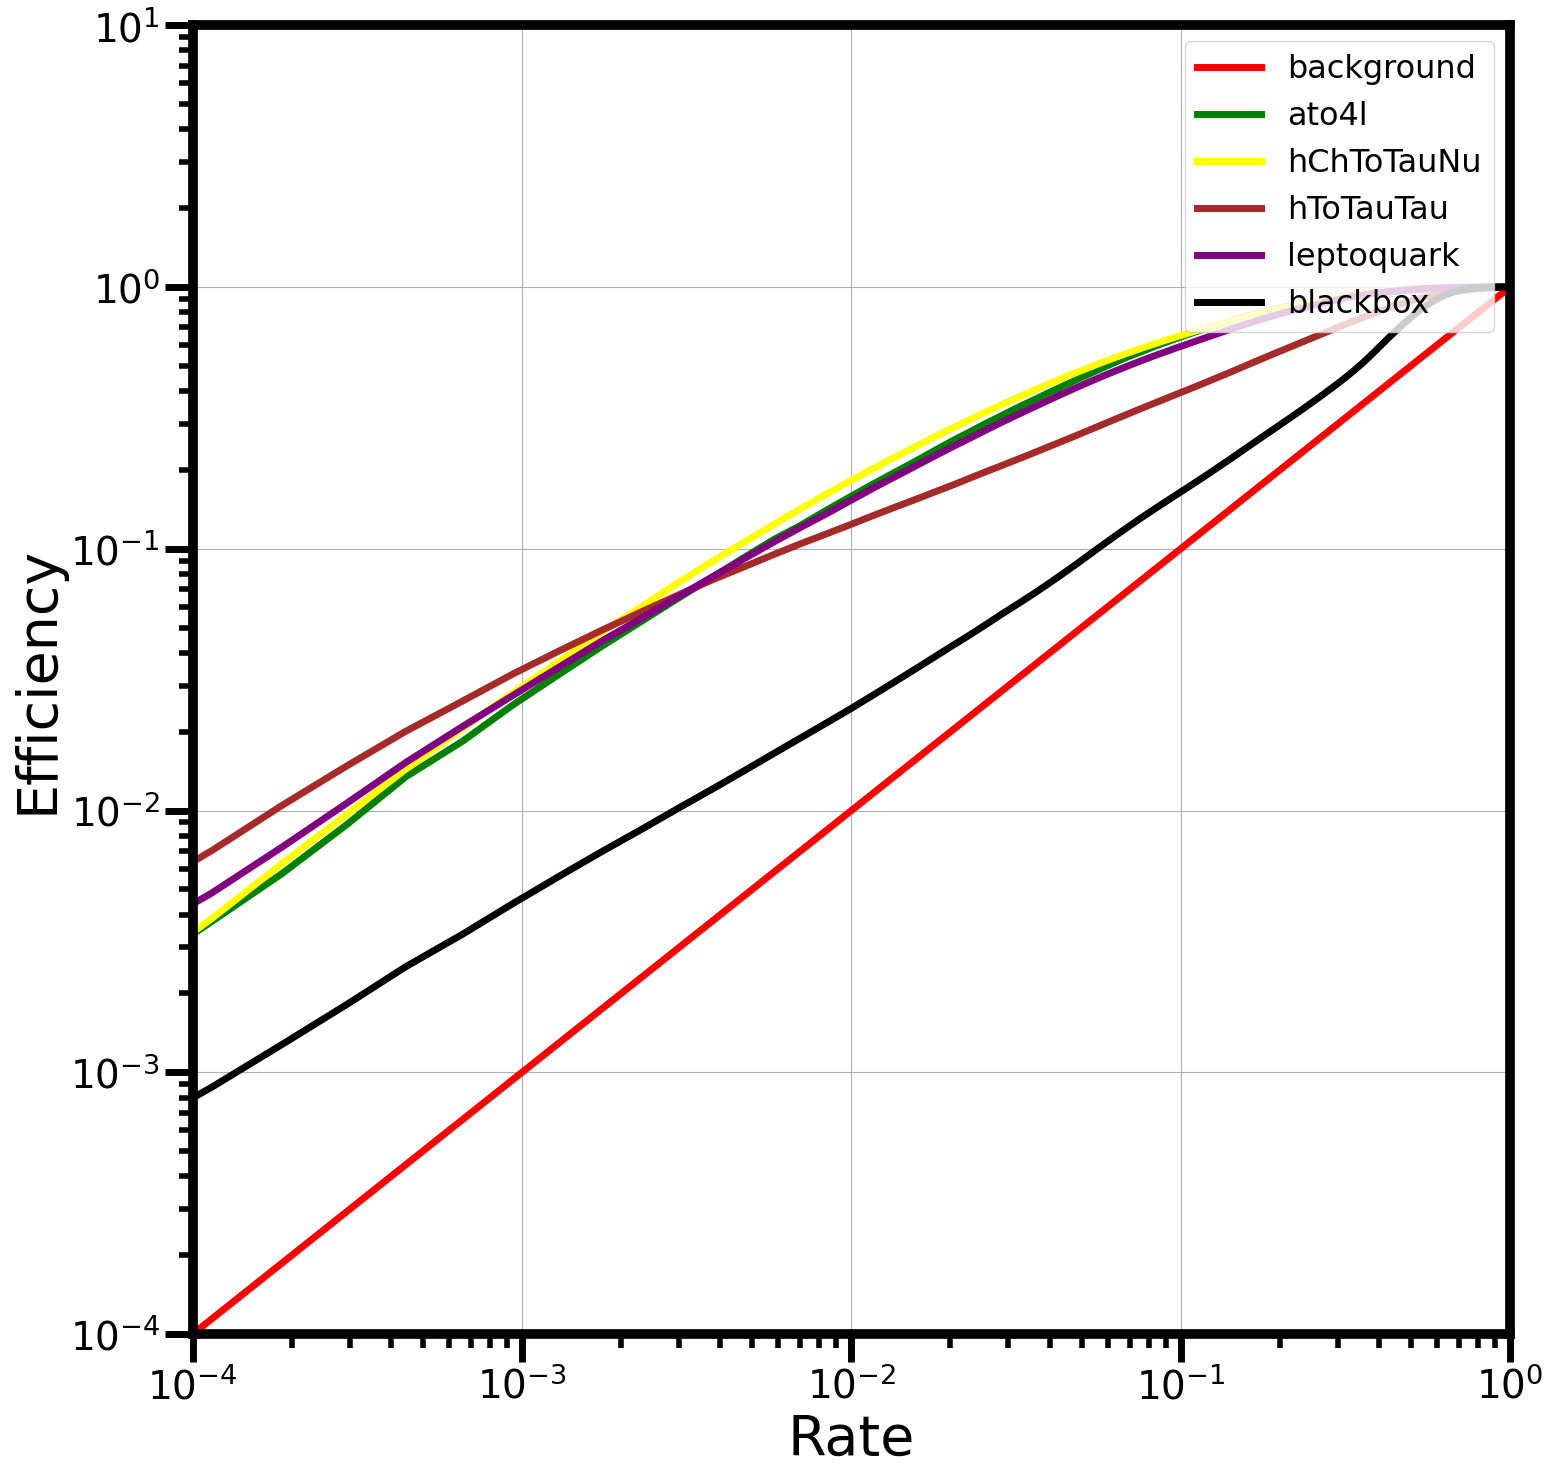

In [15]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=style.FIGURE_SIZE)


ax.plot(background_rates,labels['background']['efficiencies'], label='background', color='red', linewidth=style.LINEWIDTH)
ax.plot(background_rates,labels['ato4l']['efficiencies'], label='ato4l', color='green', linewidth=style.LINEWIDTH)
ax.plot(background_rates,labels['hChToTauNu']['efficiencies'], label='hChToTauNu', color='yellow', linewidth=style.LINEWIDTH)
ax.plot(background_rates,labels['hToTauTau']['efficiencies'], label='hToTauTau', color='brown', linewidth=style.LINEWIDTH)
ax.plot(background_rates,labels['leptoquark']['efficiencies'], label='leptoquark', color='purple', linewidth=style.LINEWIDTH)
ax.plot(background_rates,labels['blackbox']['efficiencies'], label='blackbox', color='black', linewidth=style.LINEWIDTH)

ax.grid(True)
ax.set_ylabel('Efficiency')
ax.set_xlabel('Rate')
ax.legend(loc='upper right')
ax.set_xlim(0.0001,1)
ax.set_ylim(0.0001,10)
ax.set_xscale("log")
ax.set_yscale("log")